# I - Préliminaires - Fonctions utiles

In [ ]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    from http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    :param cm: (numpy matrix) confusion matrix
    :param classes: [str]
    :param normalize: (bool)
    :param title: (str)
    :param cmap: (matplotlib color map)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
    plt.figure(figsize=(8, 8))   
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')

# II - Entraînement d'un CNN pour la classification sur CIFAR10

### II.1. Chargement et Dimensionnement de la base CIFAR10

In [3]:
from keras import backend as K
print(K.backend())

tensorflow


In [4]:
from keras.datasets import cifar10

Réduction de la taille du dataset (pour accélérer l'apprentissage), et standardisation des données

In [5]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
print("Dimension de la base d'apprentissage CIFAR10 :",x_train_full.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train_full.shape)
print("Dimension de la base de test CIFAR10 :",x_test_full.shape)

Dimension de la base d'apprentissage CIFAR10 : (50000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (50000, 1)
Dimension de la base de test CIFAR10 : (10000, 32, 32, 3)


In [6]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [7]:
n_training_samples = 5000
n_other_samples = 2000

def standardize(img_data):
    img_data_mean = np.mean(img_data, axis=(1,2), keepdims=True)
    img_data_std = np.std(img_data, axis=(1,2), keepdims=True)
    img_data = (img_data - img_data_mean) / img_data_std
    return img_data

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full), size=n_other_samples, replace=False)

n_valid = n_other_samples // 2
val_ids = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val_initial, y_val = x_test_full[val_ids], y_test_full[val_ids]
x_test_initial, y_test = x_test_full[test_ids], y_test_full[test_ids]

x_train = standardize(x_train_initial)
x_val = standardize(x_val_initial)
x_test = standardize(x_test_initial)

print("Dimension de notre base d'apprentissage :",x_train.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train.shape)
print("Dimension de notre base de validation :",x_val.shape)
print("Dimension de notre base de test :",x_test.shape)


Dimension de notre base d'apprentissage : (5000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (5000, 1)
Dimension de notre base de validation : (1000, 32, 32, 3)
Dimension de notre base de test : (1000, 32, 32, 3)


On affiche quelques images d'entraînement avec leur étiquette...

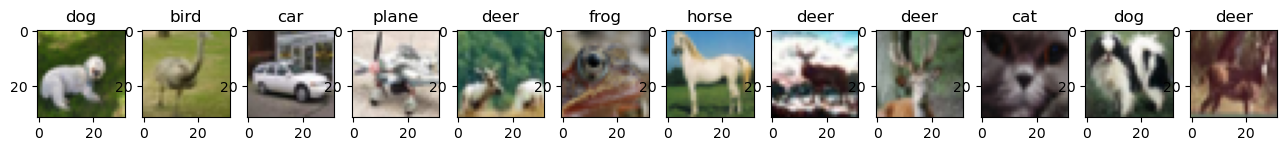

In [8]:
n_display = 12
random_ids = np.random.choice(len(x_train), n_display, replace=False)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_train_initial[random_ids[k]])
    axarr[k].title.set_text(classes[y_train[random_ids[k]][0]])

In [9]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print("Dimension des matrices d'étiquette de classe (train) :",y_train.shape)
print("Dimension des matrices d'étiquette de classe (val) :",y_val.shape)
print("Dimension des matrices d'étiquette de classe (test) :",y_test.shape)

Dimension des matrices d'étiquette de classe (train) : (5000, 10)
Dimension des matrices d'étiquette de classe (val) : (1000, 10)
Dimension des matrices d'étiquette de classe (test) : (1000, 10)


### II.2. Definition de l'architecture du CNN

Un simple réseau convolutionnel... 

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Activation, BatchNormalization
from keras.regularizers import l2
from keras import Input

model = Sequential()

model.add(Input(shape=(32,32,3)))

# 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.2))

# 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.3))

# 3 
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D((2,2)))
model.add(Dropout(0.3))

# Classification
model.add(Flatten())
model.add(Dense(256, activation='relu')) 
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

On enregistre les poids initiaux pour plus tard...

In [13]:
weights_init = model.get_weights()

### II.3. Definition de la fonction de coût et choix de l'algorithme d'optimisation

In [14]:
from keras.optimizers import Adam, SGD

opt = SGD(learning_rate=0.01,momentum=0.9)
#opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt,
             loss='categorical_crossentropy',
             metrics=['acc'])

On affiche un résumé de la structure du modèle...

In [15]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,018 (3.11 MB)

 Trainable params: 814,570 (3.11 MB)

 Non-trainable params: 448 (1.75 KB)

None


### II.4. Entraînement du CNN

*Definition du callback. A passer en première lecture.*

In [16]:
from keras.callbacks import Callback
from keras.callbacks import ModelCheckpoint
import time

class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)
time_callback = TimeHistory()

checkpoint = ModelCheckpoint('model_epoch_{epoch:02d}.h5', monitor='val_acc', verbose=1, save_best_only=True, mode='max', save_freq=5)

callbacks = [time_callback, checkpoint]

In [18]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_val, y_val),
                    callbacks=callbacks)

Epoch 1/20
  4/157 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - acc: 0.0651 - loss: 3.9436

c:\Users\lhenr\anaconda3\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to model_epoch_01.h5
  9/157 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - acc: 0.0705 - loss: 3.8600


Epoch 1: finished saving model to model_epoch_01.h5
 14/157 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - acc: 0.0820 - loss: 3.6643


Epoch 1: finished saving model to model_epoch_01.h5
 19/157 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - acc: 0.0896 - loss: 3.5007

...


Epoch 20: finished saving model to model_epoch_20.h5
141/157 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - acc: 0.6765 - loss: 0.9231


Epoch 20: finished saving model to model_epoch_20.h5
146/157 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - acc: 0.6767 - loss: 0.9228


Epoch 20: finished saving model to model_epoch_20.h5
151/157 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - acc: 0.6768 - loss: 0.9225


Epoch 20: finished saving model to model_epoch_20.h5
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - acc: 0.6769 - loss: 0.9224


Epoch 20: finished saving model to model_epoch_20.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - acc: 0.6788 - loss: 0.9206 - val_acc: 0.6090 - val_loss: 1.2095


Statistiques sur le temps d'entraînement d'une epoch

In [19]:
times = time_callback.times
print("Mean: {}".format(np.mean(times)))
print("Std: {}".format(np.std(times)))

Mean: 22.455113351345062
Std: 4.540089791195665


Tracé des courbes d'évolution des fonctions de coût

In [20]:
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

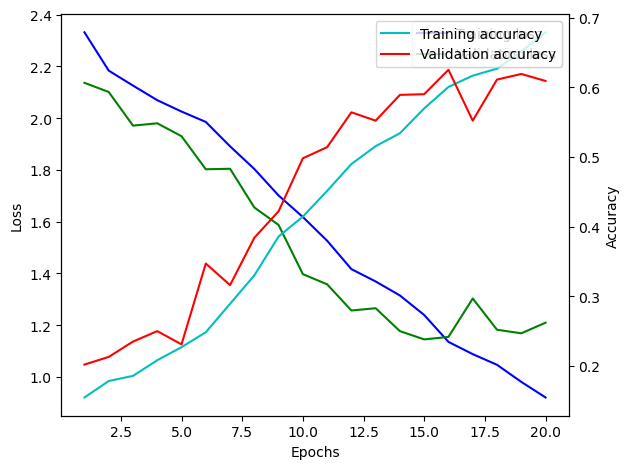

In [21]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

epochs = range(1, len(history_dict['acc']) + 1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.plot(epochs, loss_values, color='b', label='Training loss')
ax1.plot(epochs, val_loss_values, color='g', label='Validation loss')
ax1.tick_params(axis='y')
plt.legend()

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax2.set_ylabel('Accuracy')  # we already handled the x-label with ax1
ax2.plot(epochs, acc_values, color='c', label='Training accuracy')
ax2.plot(epochs, val_acc_values, color='r', label='Validation accuracy')
ax2.tick_params(axis='y')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.legend(loc=1)
plt.show()

### II.5. Entraînement d'un CNN avec points d'arrêt et reprises (à passer en première lecture)

Pour des entraînements plus conséquents, il est primordial d'enregistrer les modèles intermédiaires afin de ne pas tout perdre si l'apprentissage venait à s'interrompre de façon impromptue. On peut enregistrer le modèle dans un fichier .hdf

Si vous regardez plus attentivement, lors de l'entrainement précédent nous avons crée un object **ModelCheckpoint**. Il permet d'enregistrer le meilleur modèle (au sens d'une metrique à préciser) dans un fichier nommé *my_model.h5*. Verifiez que ce fichier se trouve bien votre espace de travail.

L'argument ***period*** de l'objet ModelCheckpoint vous permet de definir la fréquence des enregistrements.

In [22]:
from keras.models import load_model

Une fois le modele obtenu, on peut l'enregister et le recharger comme ceci: load_model(filepath)

In [23]:
from keras.models import load_model

import pathlib
file = pathlib.Path('my_model.h5')
if file.exists():
    model = load_model('my_model.h5')
    opt_loaded = SGD(learning_rate=0.01,momentum=0.9)
    model.compile(optimizer=opt_loaded, loss='categorical_crossentropy', metrics=['acc'])
else:
    model.set_weights(weights_init)
callbacks = [time_callback,checkpoint]
history_2 = model.fit(x_train, y_train, batch_size=8, epochs=10, verbose=1, validation_data=(x_val, y_val),
                      callbacks = callbacks)

Epoch 1/10
  3/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - acc: 0.4514 - loss: 1.4596


Epoch 1: finished saving model to model_epoch_01.h5
  9/625 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - acc: 0.5401 - loss: 1.2580


Epoch 1: finished saving model to model_epoch_01.h5
 14/625 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - acc: 0.5429 - loss: 1.2727


Epoch 1: finished saving model to model_epoch_01.h5
 19/625 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - acc: 0.5481 - loss: 1.2957


Epoch 1: finished saving model to model_epoch_01.h5
 24/625 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - acc: 0.5511 - loss: 1.3012

...


Epoch 10: finished saving model to model_epoch_10.h5
609/625 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - acc: 0.6098 - loss: 1.1909


Epoch 10: finished saving model to model_epoch_10.h5
614/625 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - acc: 0.6097 - loss: 1.1913


Epoch 10: finished saving model to model_epoch_10.h5
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - acc: 0.6096 - loss: 1.1917


Epoch 10: finished saving model to model_epoch_10.h5
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - acc: 0.6095 - loss: 1.1921


Epoch 10: finished saving model to model_epoch_10.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - acc: 0.5958 - loss: 1.2456 - val_acc: 0.6170 - val_loss: 1.2144


# III - Test et Évaluation du modèle en prédiction

### III.1. Test du modèle sur les données de test

Testons la prédiction de notre modèle sur quelques images de test au hasard...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


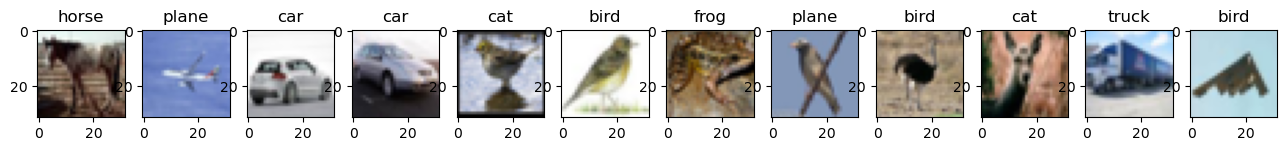

In [24]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
pred = np.argmax(model.predict(x_test[random_ids]), axis=1)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_test_initial[random_ids[k]])
    axarr[k].title.set_text(classes[pred[k]])

Vos premiers résultats semblent-ils corrects ?

Hum ! Affichons à présent la précision sur l'ensemble de votre base :

In [25]:
print("Précision du réseau sur les {} images d'entraînement : {:.2f} %".format(n_training_samples, 100 * history_dict['acc'][-1]))
print("Précision du réseau sur les {} images de validation : {:.2f} %".format(n_valid, 100 * history_dict['val_acc'][-1]))

Précision du réseau sur les 5000 images d'entraînement : 67.88 %
Précision du réseau sur les 1000 images de validation : 60.90 %


In [26]:
def accuracy_per_class(model):
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=np.int64)
    
    pred = np.argmax(model.predict(x_test), axis=1)
    for i in range(len(y_test)):
        confusion_matrix[np.argmax(y_test[i]), pred[i]] += 1
    
    print("{:<10} {:^10}".format("Classe", "Précision (%)"))
    total_correct = 0
    for i in range(n_classes):
        class_total = confusion_matrix[i, :].sum()
        class_correct = confusion_matrix[i, i]
        total_correct += class_correct
        percentage_correct = 100.0 * float(class_correct) / class_total
        print('{:<10} {:^10.2f}'.format(classes[i], percentage_correct))
    test_acc = 100.0 * float(total_correct) / len(y_test)
    print("Précision du réseau sur les {} images de test : {:.2f} %".format(len(y_test),test_acc))
    return confusion_matrix

confusion_matrix = accuracy_per_class(model)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Classe     Précision (%)
plane        52.94   
car          79.63   
bird         24.56   
cat          72.82   
deer         54.35   
dog          47.22   
frog         50.00   
horse        42.86   
ship         83.49   
truck        66.34   
Précision du réseau sur les 1000 images de test : 57.70 %


### III.2. Matrices de Confusion

Les matrices de confusion nous renseignent plus précisément sur la nature des erreurs commises par notre modèle.

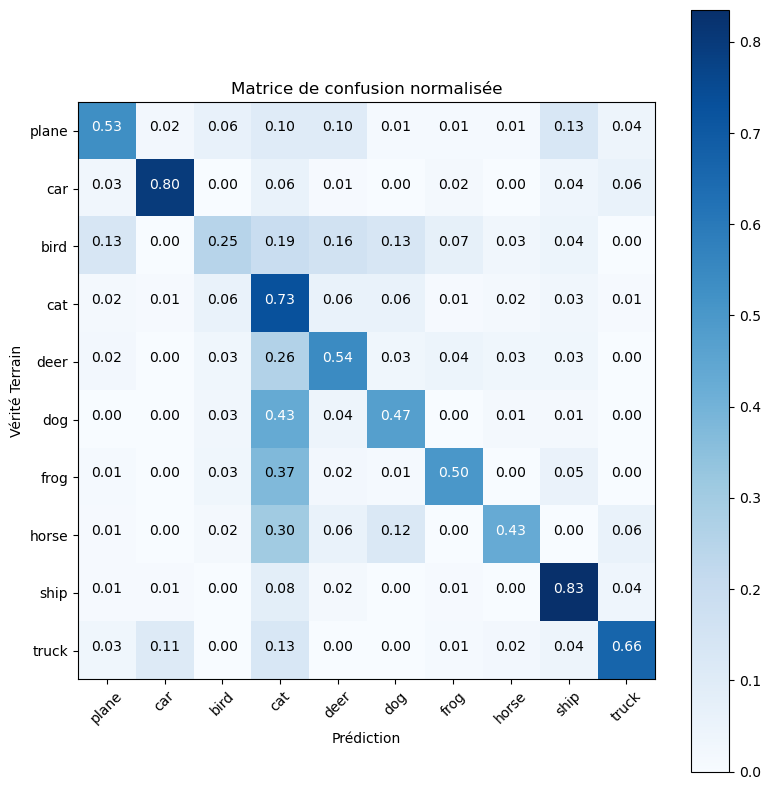

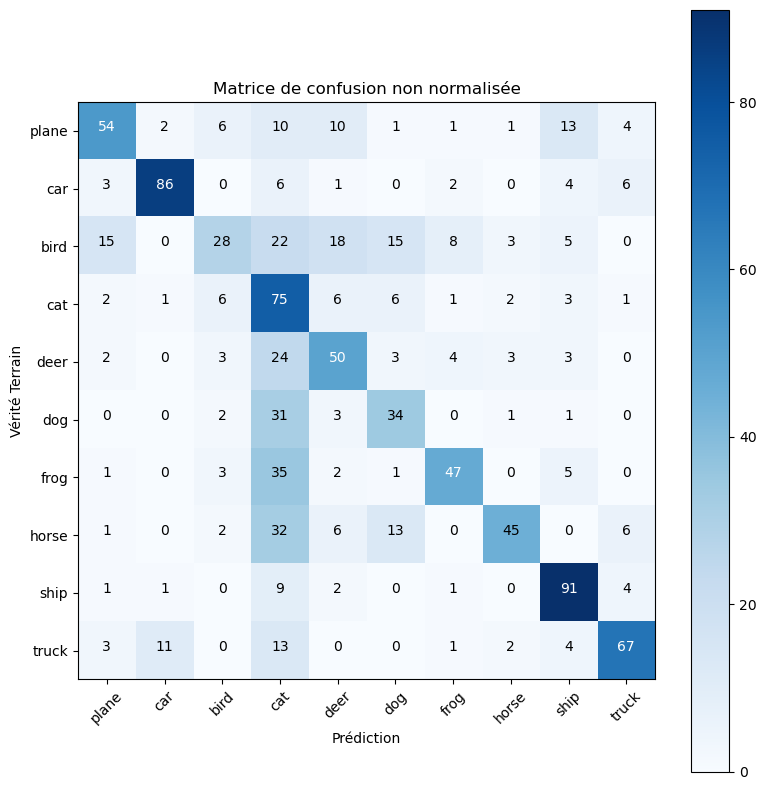

In [27]:
# Plot normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes, normalize=True,
                      title='Matrice de confusion normalisée')

# Plot non-normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes,
                      title='Matrice de confusion non normalisée')

# IV - Visualisation des zones d'activation

In [28]:
from keras.models import Model

reduced_model = Model(inputs=model.inputs, outputs=model.layers[1].output)
reduced_model.summary()

Model: "functional_76"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,024 (4.00 KB)

 Trainable params: 960 (3.75 KB)

 Non-trainable params: 64 (256.00 B)

In [29]:
feature_maps = reduced_model.predict(x_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [30]:
def get_mask(img):
    # img shape: (32, 32, 3)
    fmap = reduced_model.predict(img[np.newaxis, ...])[0]
    fmap_positive = np.maximum(fmap, 0)
    mask = np.sum(fmap_positive, axis=2)
    mask = mask / np.max(mask)
    return mask

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


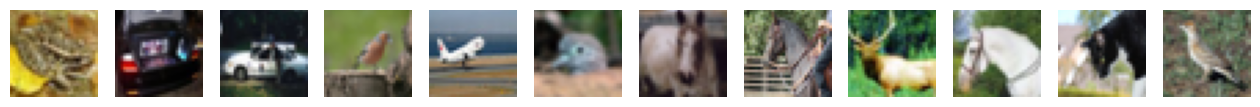

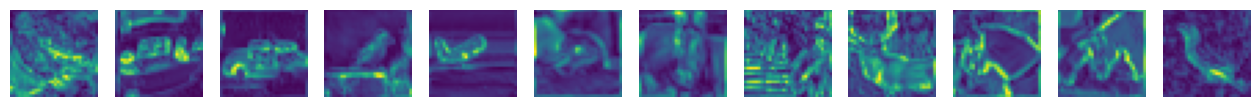

In [31]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
f, rd_img = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    img = x_test_initial[random_ids[k]]
    rd_img[k].imshow(img)
    rd_img[k].axis('off')
f, rd_maps = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    mask = get_mask(x_test[random_ids[k]])
    rd_maps[k].imshow(mask, cmap='viridis')
    rd_maps[k].axis('off')

In [32]:
# Fonction pour visualiser les activation maps d'une couche spécifique
def visualize_activation_maps(layer_index, layer_name, num_samples=3, num_filters=8):

    # Créer un modèle qui sort les activations à la couche spécifiée
    activation_model = Model(inputs=model.inputs, 
                            outputs=model.layers[layer_index].output)
    
    # Sélectionner des images aléatoires
    sample_ids = np.random.choice(len(x_test), num_samples, replace=False)
    
    # Visualiser pour chaque image
    fig, axes = plt.subplots(num_samples, num_filters + 1, figsize=(16, 3*num_samples))
    fig.suptitle(f'Activation Maps - {layer_name}', fontsize=16, fontweight='bold')
    
    for i, img_id in enumerate(sample_ids):
        # Image originale
        img = x_test_initial[img_id]
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Image originale\n(classes)', fontsize=10)
        axes[i, 0].axis('off')
        
        # Obtenir les activation maps
        activations = activation_model.predict(x_test[img_id:img_id+1], verbose=0)
        
        # Nombre total de filtres
        num_total_filters = activations.shape[-1]
        
        # Afficher les premiers num_filters filtres (ou tous s'il y a moins)
        filters_to_show = min(num_filters, num_total_filters)
        
        for j in range(filters_to_show):
            # Normaliser le map
            activation_map = activations[0, :, :, j]
            activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min() + 1e-5)
            
            axes[i, j + 1].imshow(activation_map, cmap='hot')
            axes[i, j + 1].set_title(f'Filtre {j}', fontsize=9)
            axes[i, j + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return activation_model

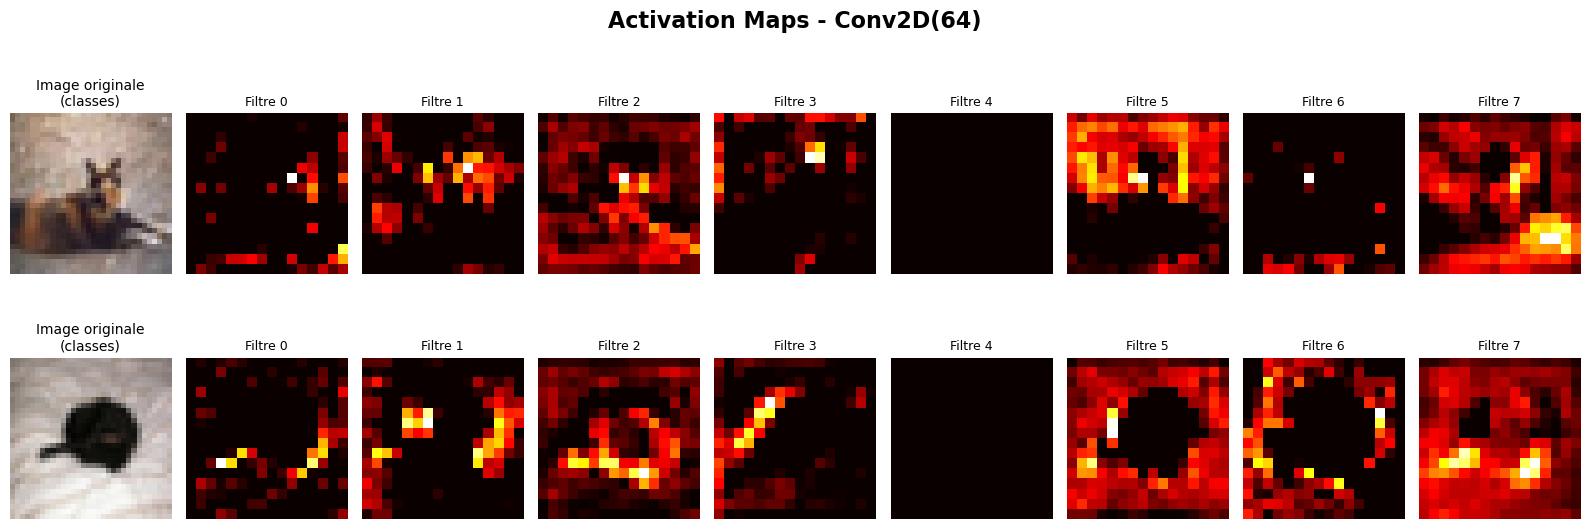

In [33]:
n_display = 2  # Nombre d'images à afficher

activation_model_layer2 = visualize_activation_maps(layer_index=5, 
                                                     layer_name='Conv2D(64)', 
                                                     num_samples=n_display, 
                                                     num_filters=8)

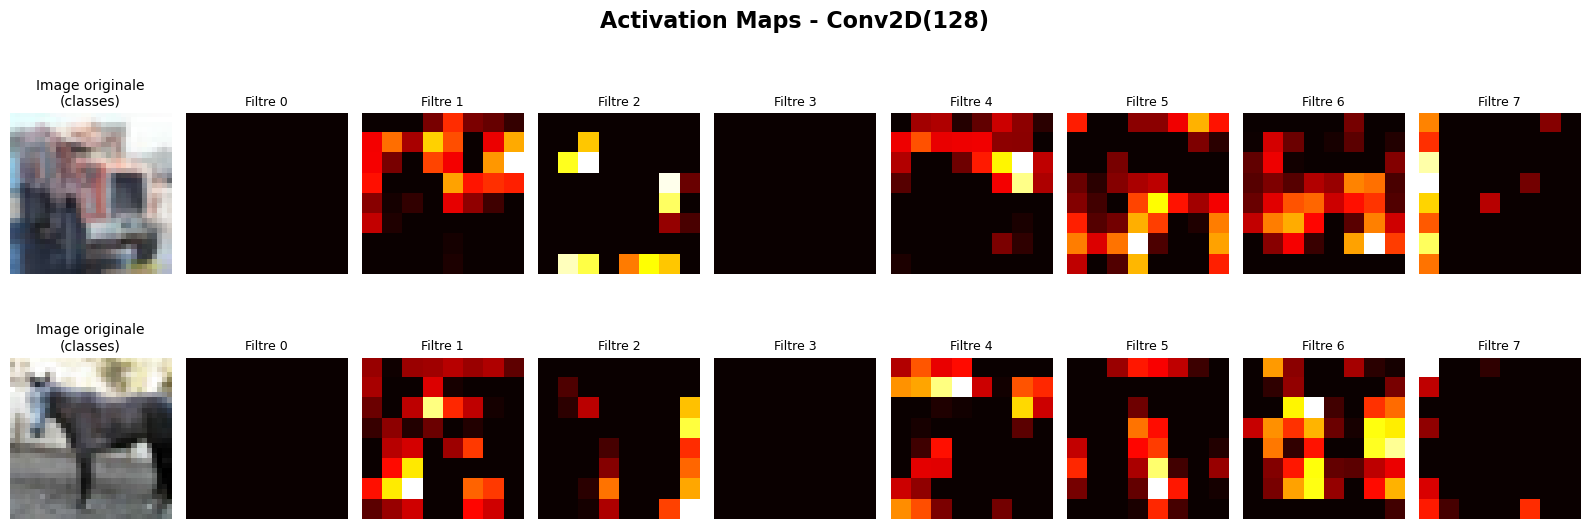

In [34]:
# Couche 3 (128 filtres) - après le deuxième MaxPool
activation_model_layer3 = visualize_activation_maps(layer_index=10, 
                                                     layer_name='Conv2D(128)', 
                                                     num_samples=n_display, 
                                                     num_filters=8)

Activations for epoch 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


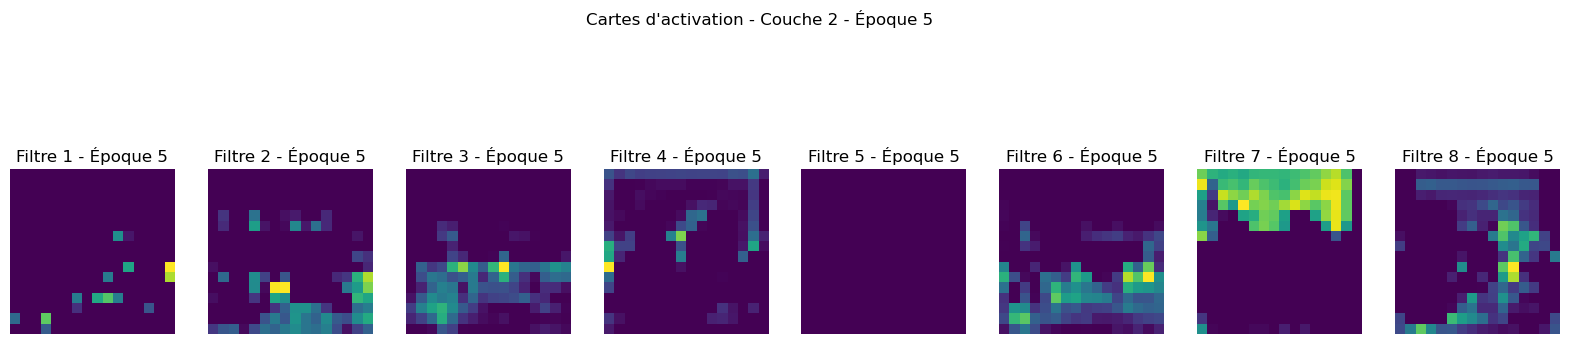

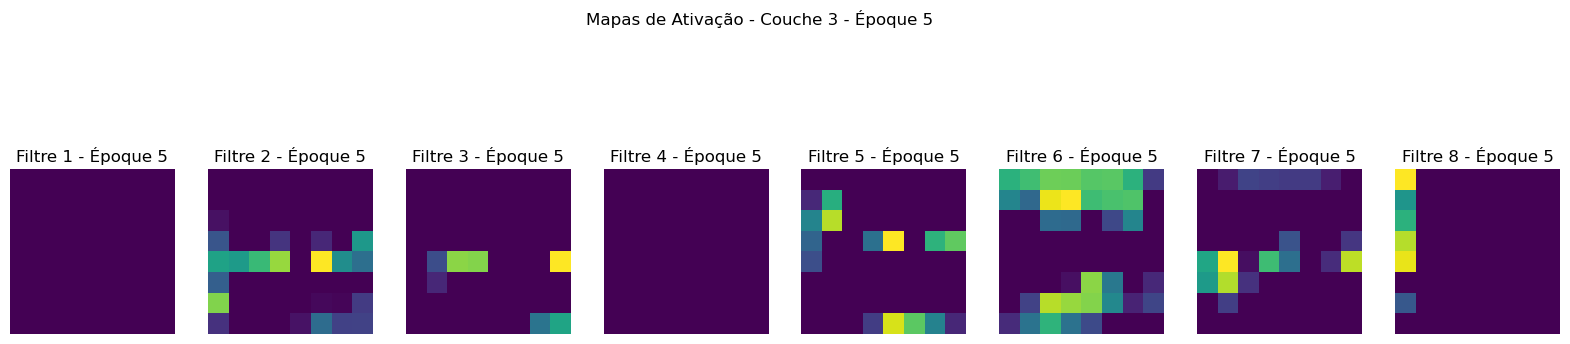

Activations for epoch 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


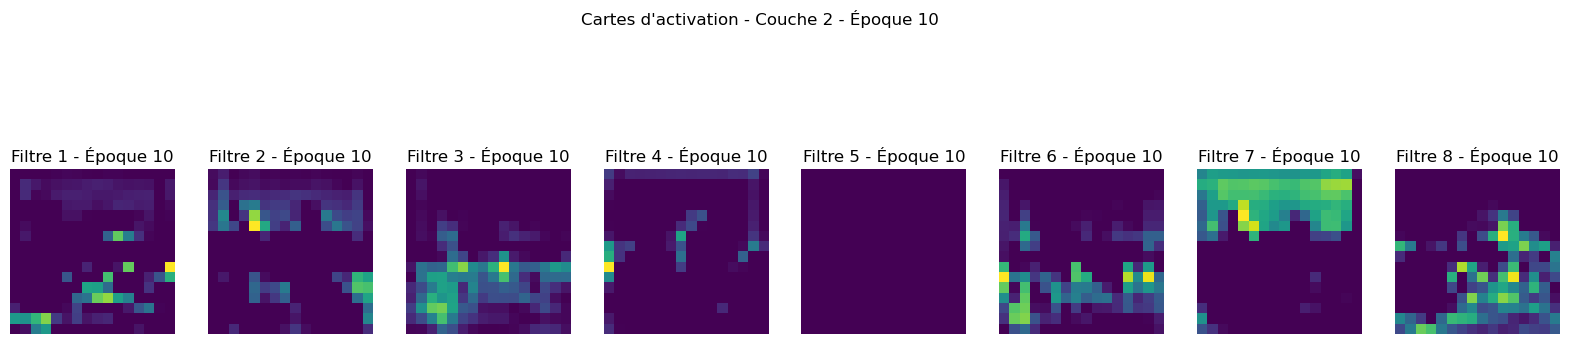

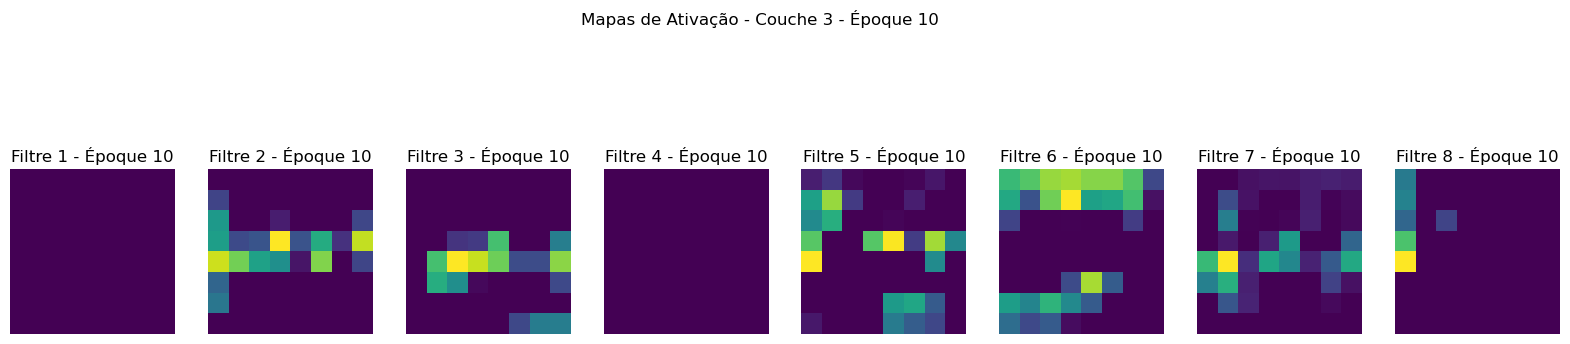

Activations for epoch 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


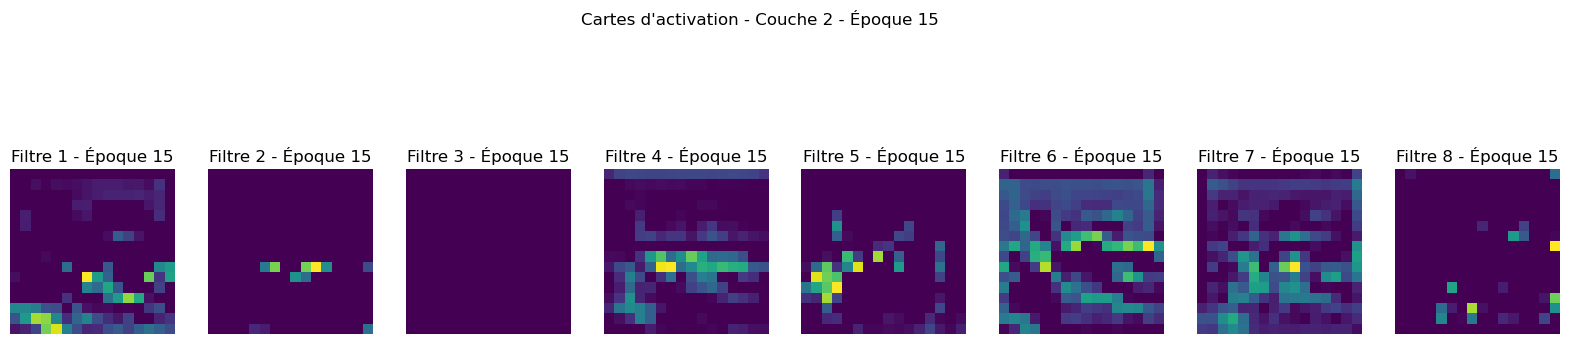

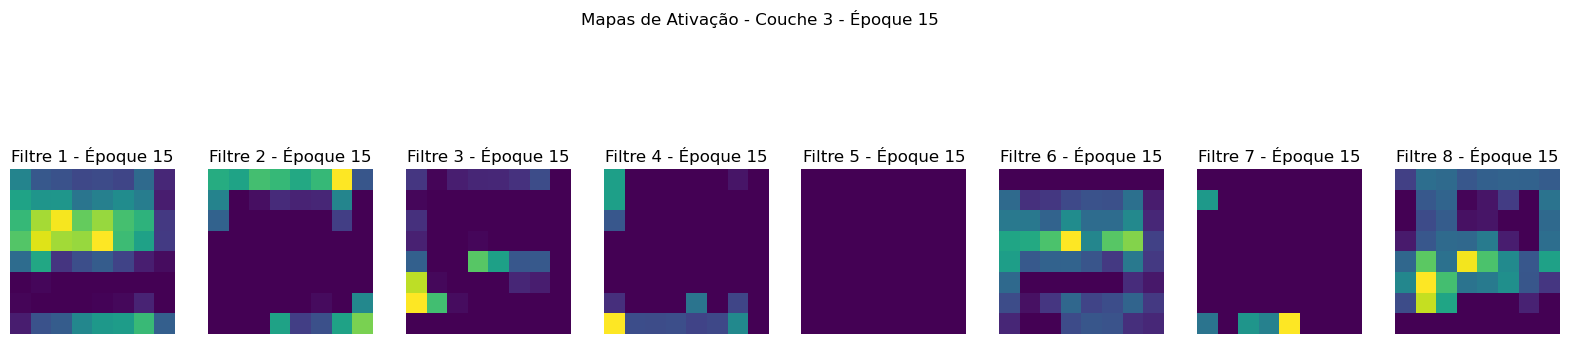

In [38]:
epochs_to_check = [5, 10,15]

for epoch in epochs_to_check:
    model_path = f'model_epoch_{epoch:02d}.h5'
    
    loaded_model = load_model(model_path)
    opt_loaded = SGD(learning_rate=0.01, momentum=0.9)
    loaded_model.compile(optimizer=opt_loaded, loss='categorical_crossentropy', metrics=['acc'])
    
    loaded_model.predict(np.zeros((1, 32, 32, 3)), verbose=0)
    print(f"Activations for epoch {epoch}")

    activation_model_layer2 = Model(inputs=loaded_model.layers[0].input, outputs=loaded_model.layers[5].output)  
    activation_model_layer3 = Model(inputs=loaded_model.layers[0].input, outputs=loaded_model.layers[10].output)  
    
    sample_images = x_test[:2] 
    
    activations_layer2 = activation_model_layer2.predict(sample_images)
    activations_layer3 = activation_model_layer3.predict(sample_images)
    
    fig, axes = plt.subplots(1, 8, figsize=(20, 5))  
    for i in range(8):
        ax = axes[i]
        ax.imshow(activations_layer2[0, :, :, i], cmap='viridis')  
        ax.set_title(f'Filtre {i+1} - Époque {epoch}')
        ax.axis('off')
    plt.suptitle(f'Cartes d\'activation - Couche 2 - Époque {epoch}')
    plt.show()
        
    fig, axes = plt.subplots(1, 8, figsize=(20, 5)) 
    for i in range(8):
        ax = axes[i]
        ax.imshow(activations_layer3[0, :, :, i], cmap='viridis')  
        ax.set_title(f'Filtre {i+1} - Époque {epoch}')
        ax.axis('off')
    plt.suptitle(f'Mapas de Ativação - Couche 3 - Époque {epoch}')
    plt.show()
        